In [3]:
import pandas as pd

In [4]:
from google.colab import files
uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset.xlsx


In [5]:
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

In [6]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [7]:
df.info()

df.describe()

df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,City,Product,Category
count,1000,1000,1000,1000,1000,987,1000,1000
unique,992,342,947,425,2,8,6,5
top,ORD100050,2025-04-16,CUST2515,Customer_359,Male,Patna,Mobile,Electronics
freq,9,10,3,8,511,135,184,354


In [10]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


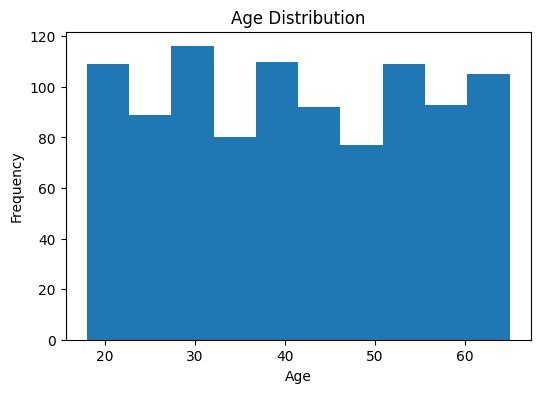

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Age'].dropna(), bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

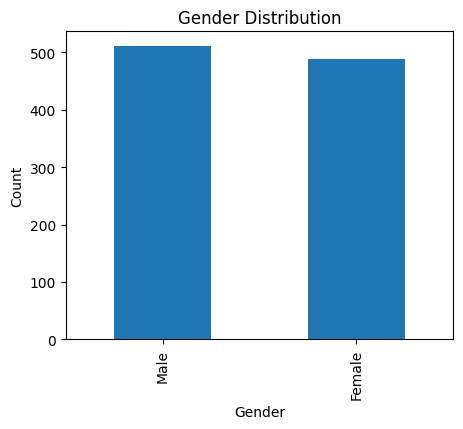

In [11]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(5,4))
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

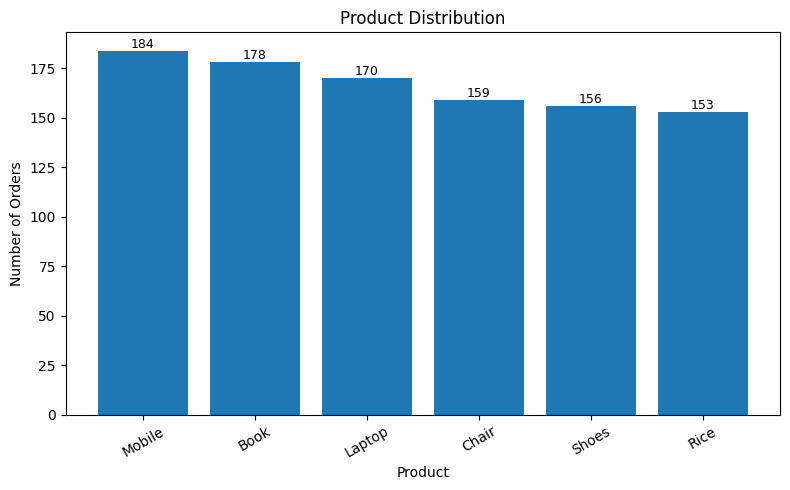

In [12]:
import matplotlib.pyplot as plt

product_counts = df['Product'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(product_counts.index, product_counts.values)

plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.title("Product Distribution")
plt.xticks(rotation=30)

# Add values above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()

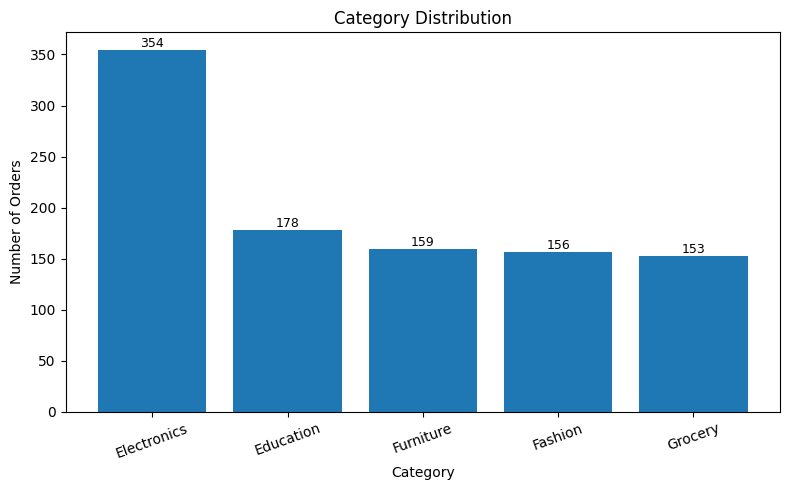

In [13]:
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(category_counts.index, category_counts.values)

plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.title("Category Distribution")
plt.xticks(rotation=20)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom',
             fontsize=9)

plt.tight_layout()
plt.show()

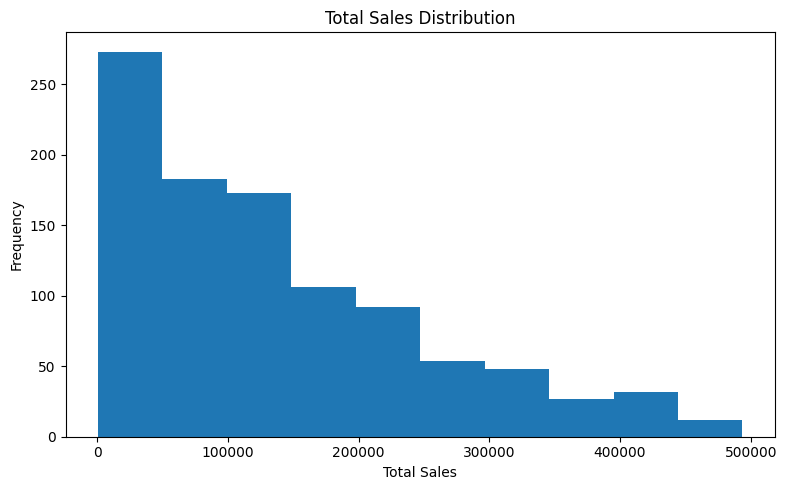

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Total_Sales'], bins=10)

plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.title("Total Sales Distribution")

plt.tight_layout()
plt.show()

In [15]:
import sqlite3
import pandas as pd

In [16]:
conn = sqlite3.connect('sales.db')

In [17]:
df.to_sql('sales', conn, if_exists='replace', index=False)

1000

In [18]:
pd.read_sql("SELECT * FROM sales LIMIT 5;", conn)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [20]:
query1 = """
SELECT Product,
       SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

result1 = pd.read_sql(query1, conn)
result1

,Product,Total_Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [29]:
query2 = """
SELECT Category,
       SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

result2 = pd.read_sql(query2, conn)
result2

,Category,Total_Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [22]:
query3 = """
SELECT City,
       SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY City
ORDER BY Total_Revenue DESC;
"""

result3 = pd.read_sql(query3, conn)
result3

,City,Total_Revenue
0,Patna,19285966.89
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39
8,None,1540617.54


In [23]:
query4 = """
SELECT Customer_Name,
       SUM(Total_Sales) AS Total_Spending
FROM sales
GROUP BY Customer_Name
ORDER BY Total_Spending DESC
LIMIT 10;
"""

result4 = pd.read_sql(query4, conn)
result4

,Customer_Name,Total_Spending
0,Customer_335,1684832.52
1,Customer_138,1305932.64
2,Customer_266,1269445.22
3,Customer_375,1196934.33
4,Customer_274,1060340.15
5,Customer_343,1025447.16
6,Customer_415,967962.17
7,Customer_355,954513.58
8,Customer_1,952753.99
9,Customer_359,941957.21


In [24]:
query5 = """
SELECT
substr(Order_Date,1,7) AS Month,
SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
"""

result5 = pd.read_sql(query5, conn)
result5

,Month,Total_Revenue
0,2025-01,10096190.73
1,2025-02,11511181.46
2,2025-03,13059899.94
3,2025-04,12222700.17
4,2025-05,10984689.25
5,2025-06,12912332.64
6,2025-07,11746226.80
7,2025-08,9448471.22
8,2025-09,9179896.29
9,2025-10,12500936.50


In [30]:
query6 = """
SELECT
Gender,
SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY Gender;
"""

result6 = pd.read_sql(query6, conn)
result6

,Gender,Total_Revenue
0,Female,66935889.02
1,Male,72463550.63


In [26]:
query7 = """
SELECT
Product,
AVG(Total_Sales) AS Average_Sales
FROM sales
GROUP BY Product
ORDER BY Average_Sales DESC;
"""

result7 = pd.read_sql(query7, conn)
result7

,Product,Average_Sales
0,Laptop,149664.755941
1,Rice,145305.302484
2,Book,140627.468539
3,Mobile,137693.332554
4,Chair,135355.732579
5,Shoes,127153.178141


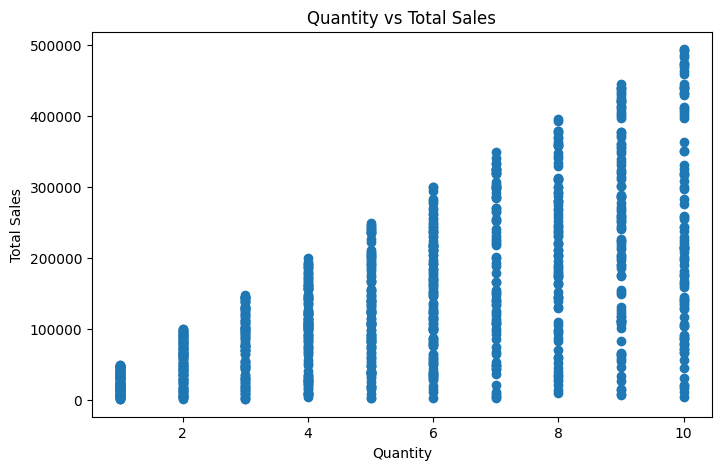

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Total_Sales'])

plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Quantity vs Total Sales")

plt.show()

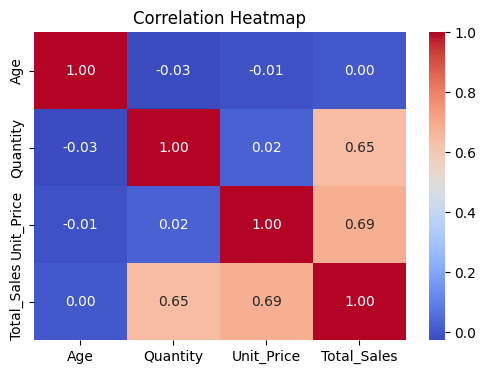

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Age','Quantity','Unit_Price','Total_Sales']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

In [31]:
result5.to_csv("Q5_Monthly_Sales_Trend.csv", index=False)
result6.to_csv("Q6_Gender_Purchasing.csv", index=False)
result7.to_csv("Q7_Average_Product_Sales.csv", index=False)

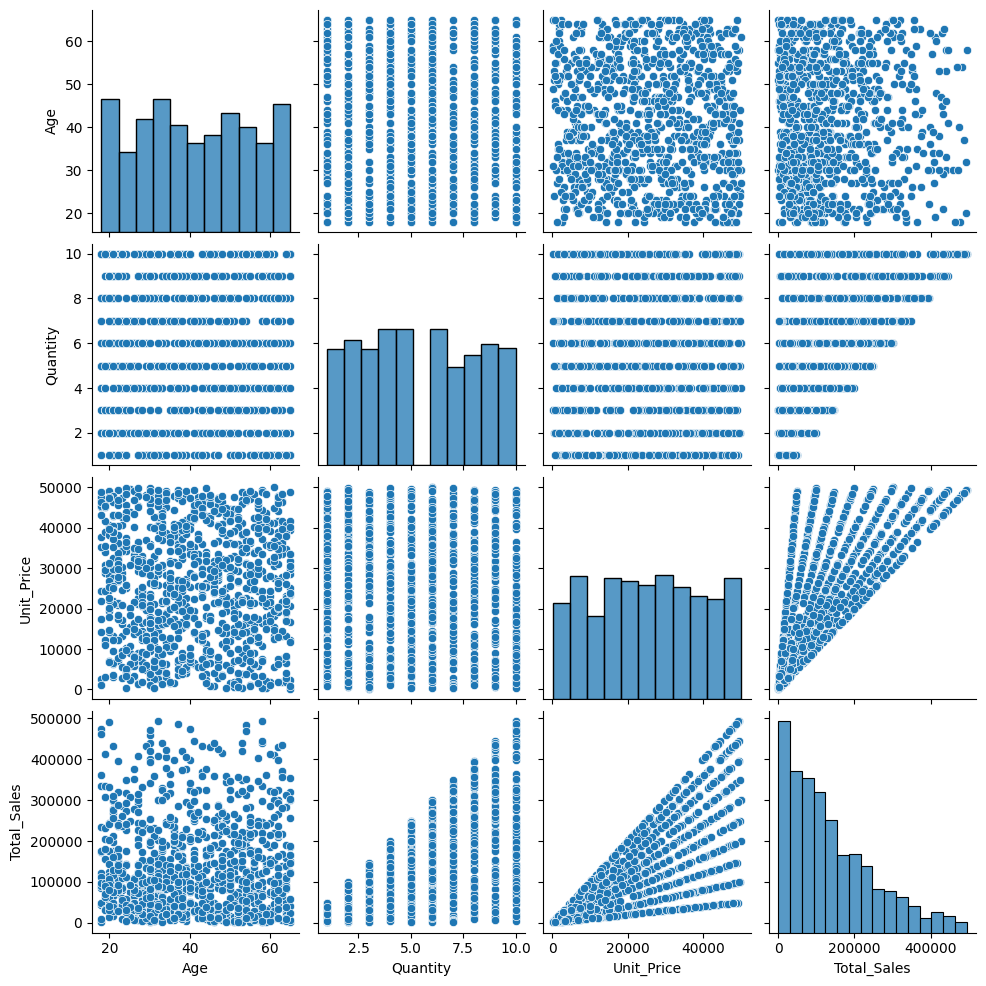

In [32]:
sns.pairplot(
    df[['Age',
        'Quantity',
        'Unit_Price',
        'Total_Sales']]
)

plt.show()

In [33]:
# Total Revenue
print("Total Revenue :", df['Total_Sales'].sum())

# Total Orders
print("Total Orders :", len(df))

# Total Customers
print("Total Customers :", df['Customer_ID'].nunique())

# Average Order Value
print("Average Order Value :", df['Total_Sales'].mean())

Total Revenue : 139399439.65
Total Orders : 1000
Total Customers : 947
Average Order Value : 139399.43965000001


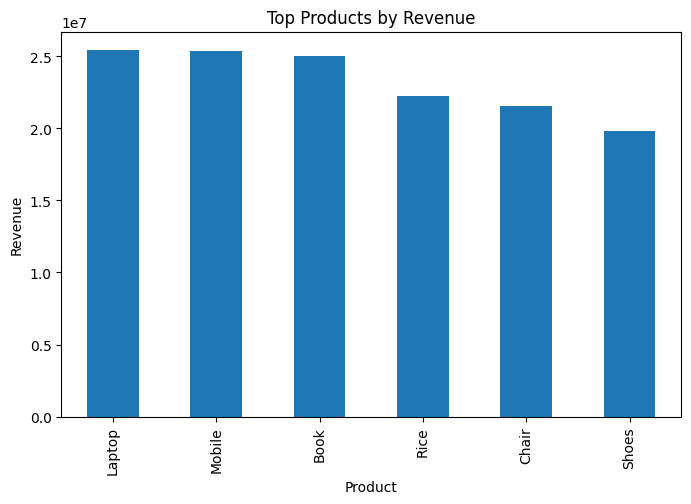

In [34]:
import matplotlib.pyplot as plt

top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')

plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

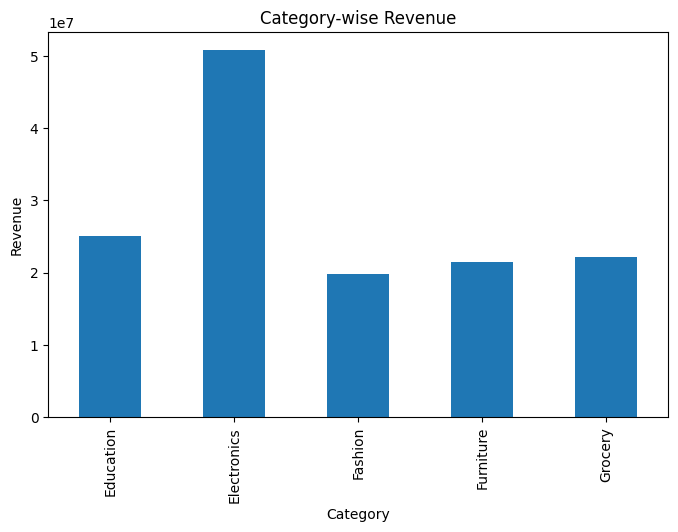

In [35]:
category_sales = df.groupby('Category')['Total_Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

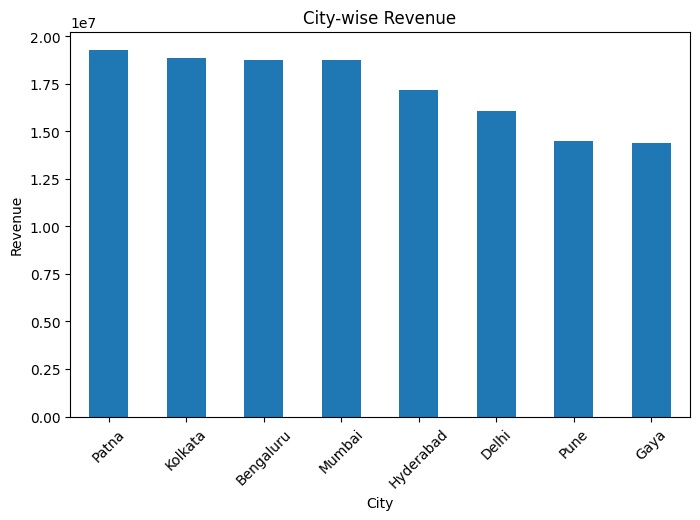

In [36]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
city_sales.plot(kind='bar')

plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

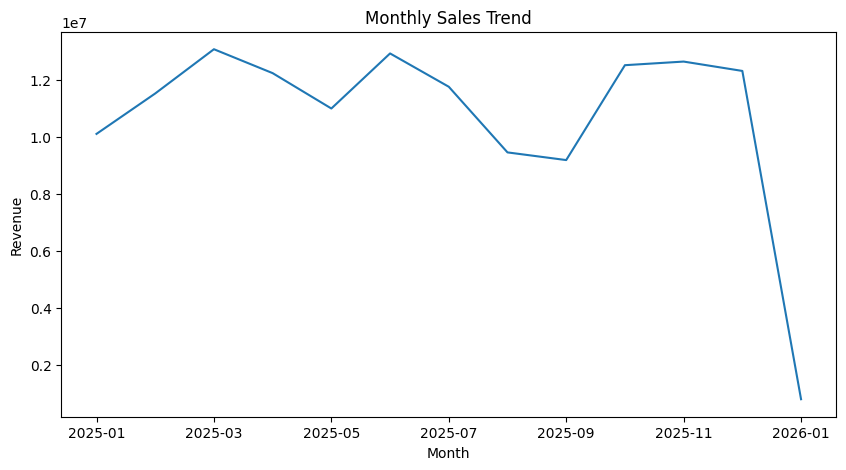

In [37]:
monthly_sales = df.groupby(df['Order_Date'].str[:7])['Total_Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

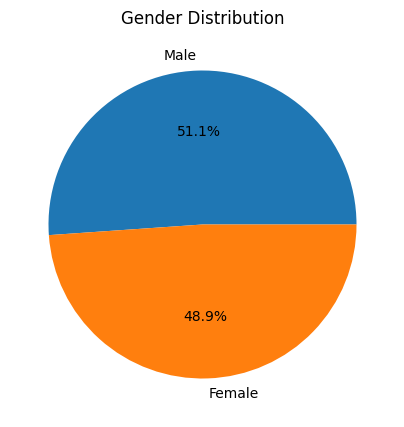

In [38]:
gender = df['Gender'].value_counts()

plt.figure(figsize=(5,5))
gender.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

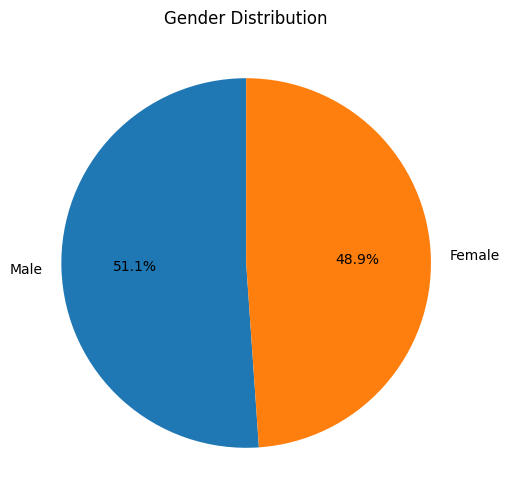

In [39]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

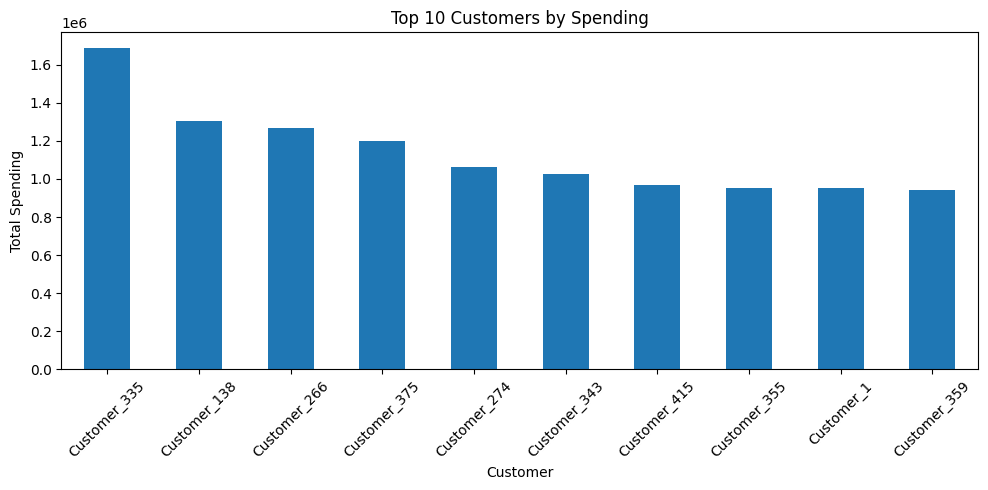

In [40]:
top_customers = (
    df.groupby('Customer_Name')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

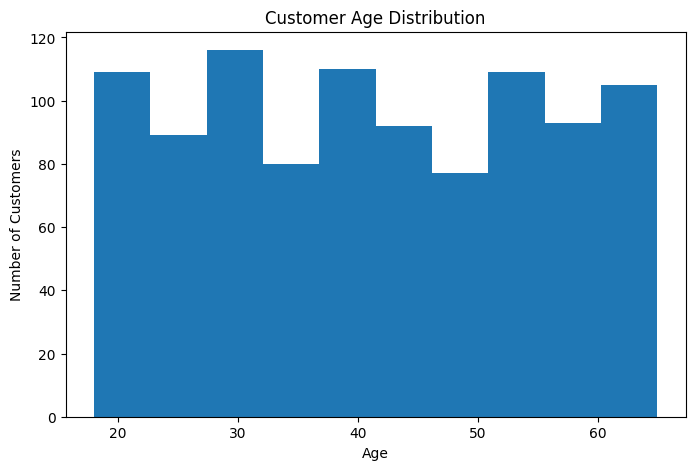

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Age'].dropna(),
    bins=10
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")

plt.show()

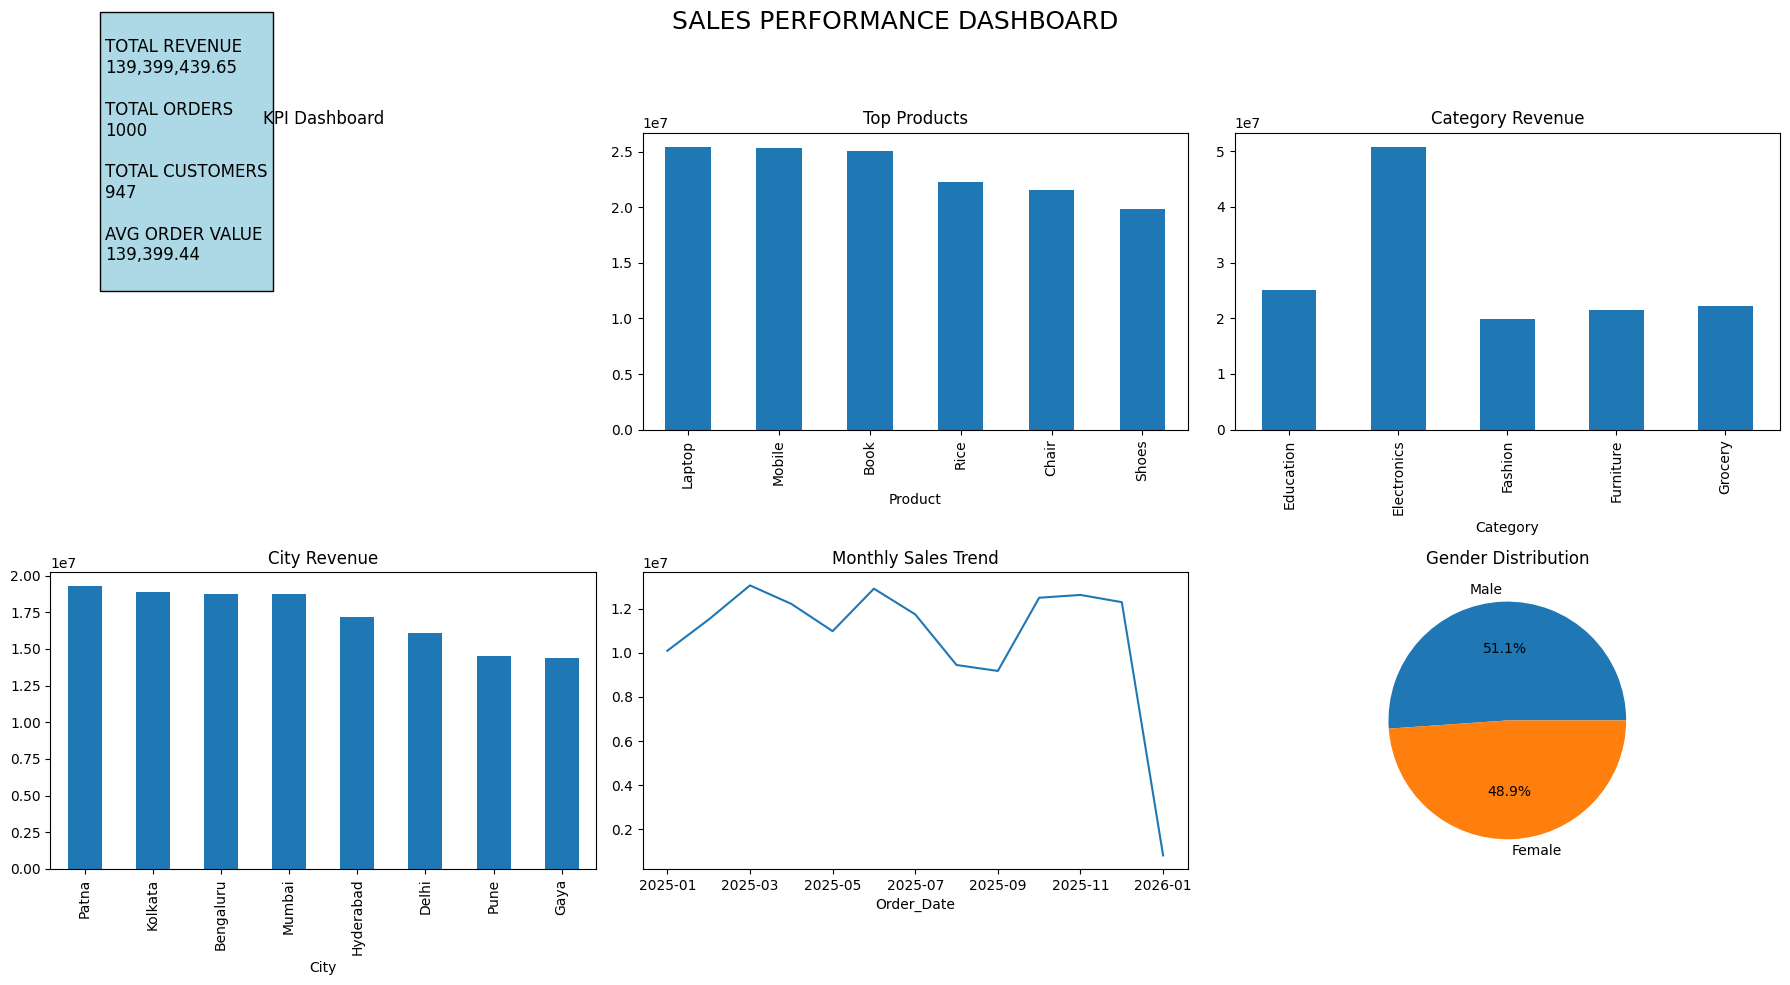

In [42]:
import matplotlib.pyplot as plt

# Create dashboard
fig = plt.figure(figsize=(18,10))

# KPI Section
ax1 = plt.subplot(2,3,1)
ax1.axis('off')

total_revenue = df['Total_Sales'].sum()
total_orders = len(df)
total_customers = df['Customer_ID'].nunique()
avg_order = df['Total_Sales'].mean()

kpi_text = f"""
TOTAL REVENUE
{total_revenue:,.2f}

TOTAL ORDERS
{total_orders}

TOTAL CUSTOMERS
{total_customers}

AVG ORDER VALUE
{avg_order:,.2f}
"""

ax1.text(
    0.1,
    0.5,
    kpi_text,
    fontsize=12,
    bbox=dict(facecolor='lightblue')
)

ax1.set_title("KPI Dashboard")

# Top Products

ax2 = plt.subplot(2,3,2)

top_products = df.groupby(
    'Product'
)['Total_Sales'].sum().sort_values(
    ascending=False
)

top_products.plot(
    kind='bar',
    ax=ax2
)

ax2.set_title("Top Products")

# Category Revenue

ax3 = plt.subplot(2,3,3)

category = df.groupby(
    'Category'
)['Total_Sales'].sum()

category.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title("Category Revenue")

# City Revenue

ax4 = plt.subplot(2,3,4)

city = df.groupby(
    'City'
)['Total_Sales'].sum().sort_values(
    ascending=False
)

city.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title("City Revenue")

# Monthly Sales

ax5 = plt.subplot(2,3,5)

monthly = df.groupby(
    df['Order_Date'].str[:7]
)['Total_Sales'].sum()

monthly.plot(
    ax=ax5
)

ax5.set_title("Monthly Sales Trend")

# Gender Distribution

ax6 = plt.subplot(2,3,6)

gender = df['Gender'].value_counts()

ax6.pie(
    gender,
    labels=gender.index,
    autopct='%1.1f%%'
)

ax6.set_title("Gender Distribution")

plt.suptitle(
    "SALES PERFORMANCE DASHBOARD",
    fontsize=18
)

plt.tight_layout()

plt.show()